In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
os.chdir('/Users/stacyli/savio/global/scratch/stacy-l/spermSV/notebooks/jupyter/20231113')
import gff_utils as gff_utils
os.chdir('/Users/stacyli/savio/global/scratch/stacy-l/spermSV')

sns.set_style('white')

# CHM13 analysis

## AluY* subfamily

In [3]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in ['894', '895', '898', '901']:
    sample_aluY = gff_utils.annotate_gff(f'output/mapping/CHM13/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.alt.fa.out.gff', motif = 'AluY')
    sample_aluY['origin'] = sample
    # sample_gff3 = gff_utils.save_gff3(f'notebooks/jupyter/20231107/{sample}_aluY_CHM13.gff', sample_aluY, return_df = False)
    samples_annotated[sample] = sample_aluY

AluY_samples = pd.concat([samples_annotated['894'], samples_annotated['895'], samples_annotated['898'], samples_annotated['901']])

Text(0.5, 0.98, 'AluY* subfamily\nread distribution')

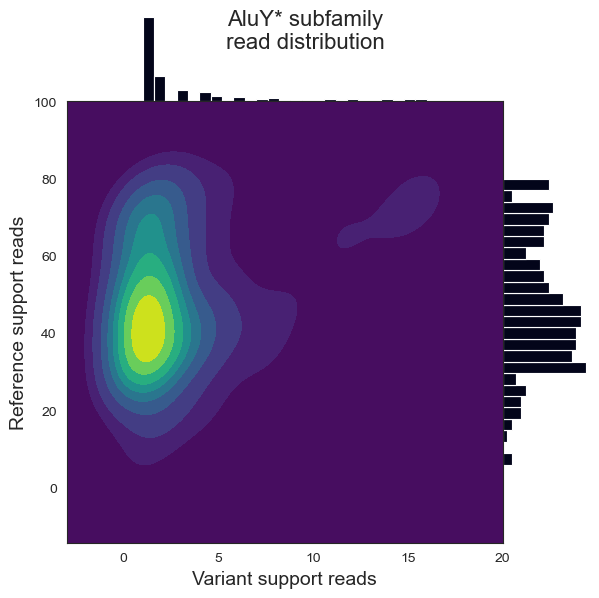

In [4]:
# use viz limits to determine the cutoff vals for filtering

g = sns.JointGrid(data=AluY_samples.query("ref_reads <= 80"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("AluY* subfamily\nread distribution", size = 16)

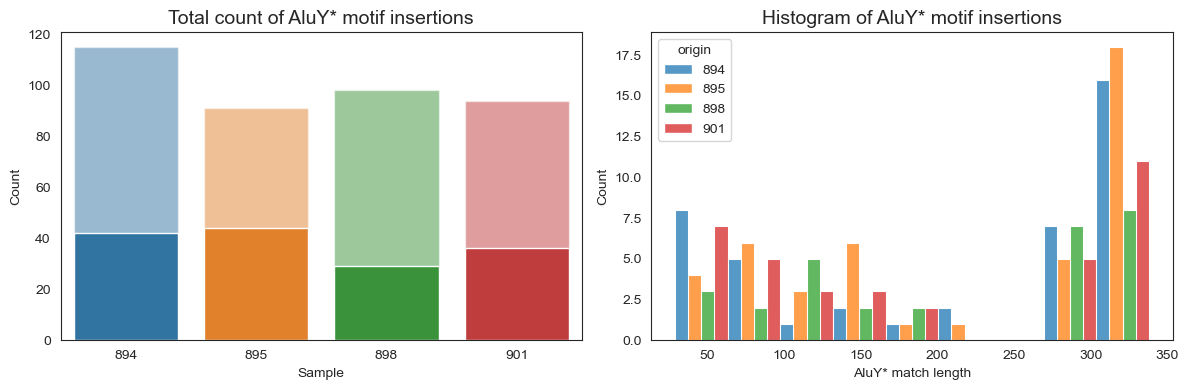

In [5]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = AluY_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = AluY_samples[~AluY_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of AluY* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = AluY_samples[~AluY_samples['#CHROM'].str.contains('_')].query("ref_reads <= 80 & alt_reads <= 10"), x = 'match_len', hue = 'origin', multiple="dodge")
axes[1].set_title("Histogram of AluY* motif insertions", size = 14)
axes[1].set_xlabel("AluY* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()

In [7]:
for sample in ['894', '895', '898', '901']:
    # export for bam filtering
    gff_utils.rnames_to_txt(f'notebooks/jupyter/20231113/{sample}_aluY_CHM13.txt', AluY_samples.query(f"origin == {sample} & ref_reads <= 80 & alt_reads <= 10"))
    # save to csv for markup
    AluY_samples.query(f"origin == {sample} & ref_reads <= 80 & alt_reads <= 10").to_csv(f'notebooks/jupyter/20231113/{sample}_aluY_CHM13.csv')

Saving .txt file to notebooks/jupyter/20231113/894_aluY_CHM13.txt ...
Saving .txt file to notebooks/jupyter/20231113/895_aluY_CHM13.txt ...
Saving .txt file to notebooks/jupyter/20231113/898_aluY_CHM13.txt ...
Saving .txt file to notebooks/jupyter/20231113/901_aluY_CHM13.txt ...


## SVA family

Quickly repeating last week's Alu analysis with a different family of active elements.

In [9]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in ['894', '895', '898', '901']:
    sample_SVA = gff_utils.annotate_gff(f'output/mapping/CHM13/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.alt.fa.out.gff', motif = 'SVA')
    sample_SVA['origin'] = sample
    sample_gff3 = gff_utils.save_gff3(f'notebooks/jupyter/20231113/{sample}_SVA_CHM13.gff', sample_SVA, return_df = False)
    samples_annotated[sample] = sample_SVA

SVA_samples = pd.concat([samples_annotated['894'], samples_annotated['895'], samples_annotated['898'], samples_annotated['901']])

Saving GFF3 file to notebooks/jupyter/20231113/894_SVA_CHM13.gff ...
Saving GFF3 file to notebooks/jupyter/20231113/895_SVA_CHM13.gff ...
Saving GFF3 file to notebooks/jupyter/20231113/898_SVA_CHM13.gff ...
Saving GFF3 file to notebooks/jupyter/20231113/901_SVA_CHM13.gff ...


Text(0.5, 0.98, 'SVA* family\nread distribution')

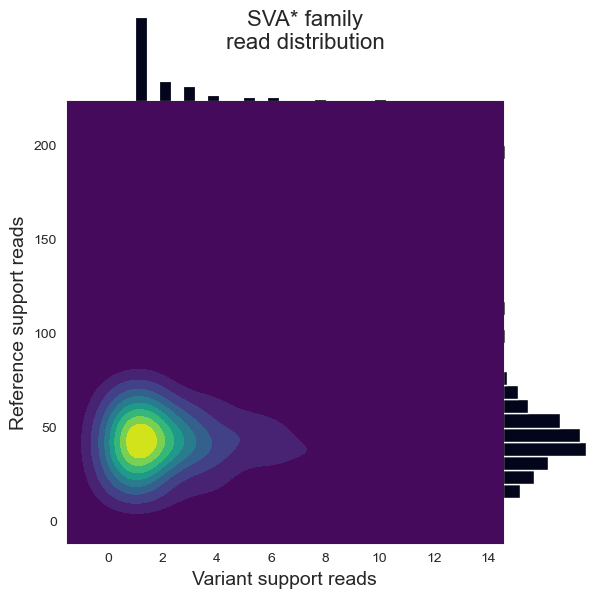

In [11]:
# use viz limits to determine the cutoff vals for filtering

g = sns.JointGrid(data=SVA_samples.query("ref_reads <= 200"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("SVA* family\nread distribution", size = 16)

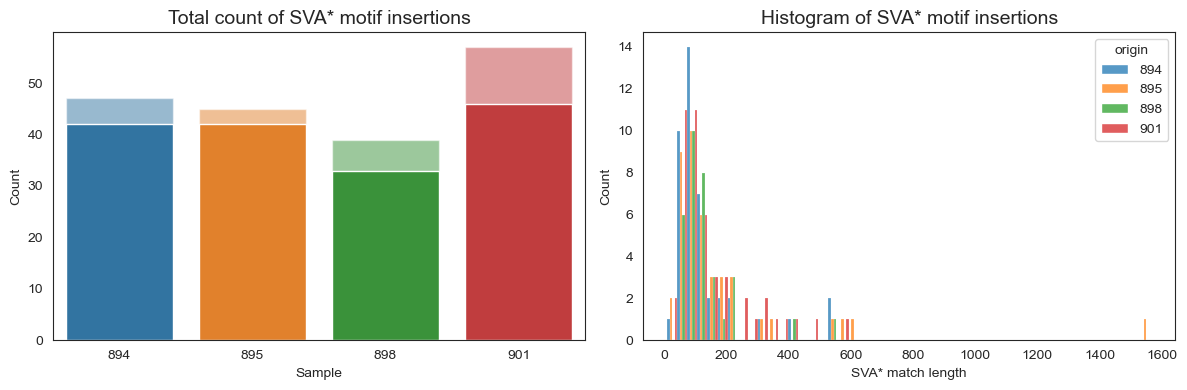

In [12]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = SVA_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = SVA_samples[~SVA_samples['#CHROM'].str.contains('_')].query("ref_reads <= 70 & alt_reads <= 5"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of SVA* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = SVA_samples[~SVA_samples['#CHROM'].str.contains('_')].query("ref_reads <= 70 & alt_reads <= 5"), x = 'match_len', hue = 'origin', multiple="dodge")
axes[1].set_title("Histogram of SVA* motif insertions", size = 14)
axes[1].set_xlabel("SVA* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()

## L1 family

Same as above.

In [13]:
# save GFFs & create master table for plotting

samples_annotated = dict()
for sample in ['894', '895', '898', '901']:
    sample_L1 = gff_utils.annotate_gff(f'output/mapping/CHM13/sniffles/mosaic/single_sample/{sample}.vcf.gz', f'output/mapping/hg38/sniffles/mosaic/single_sample/{sample}.alt.fa.out.gff', motif = 'L1')
    sample_L1['origin'] = sample
    sample_gff3 = gff_utils.save_gff3(f'notebooks/jupyter/20231113/{sample}_L1_CHM13.gff', sample_SVA, return_df = False)
    samples_annotated[sample] = sample_L1

L1_samples = pd.concat([samples_annotated['894'], samples_annotated['895'], samples_annotated['898'], samples_annotated['901']])

Saving GFF3 file to notebooks/jupyter/20231113/894_L1_CHM13.gff ...
Saving GFF3 file to notebooks/jupyter/20231113/895_L1_CHM13.gff ...
Saving GFF3 file to notebooks/jupyter/20231113/898_L1_CHM13.gff ...
Saving GFF3 file to notebooks/jupyter/20231113/901_L1_CHM13.gff ...


Text(0.5, 0.98, 'L1* family\nread distribution')

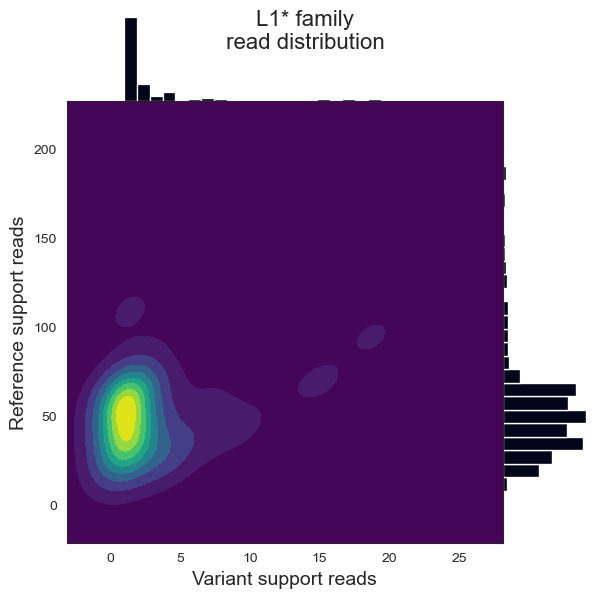

In [15]:
# no viz limits set here: high y axis driven by outliers

g = sns.JointGrid(data=L1_samples.query("ref_reads <= 200"), x="alt_reads", y="ref_reads", space=0)
g.plot_joint(sns.kdeplot, fill=True, thresh=0, cmap="viridis",)
g.plot_marginals(sns.histplot, color="#03051A", alpha=1, bins=25)
g.set_axis_labels(xlabel = "Variant support reads", ylabel = "Reference support reads", size = 14)
plt.suptitle("L1* family\nread distribution", size = 16)

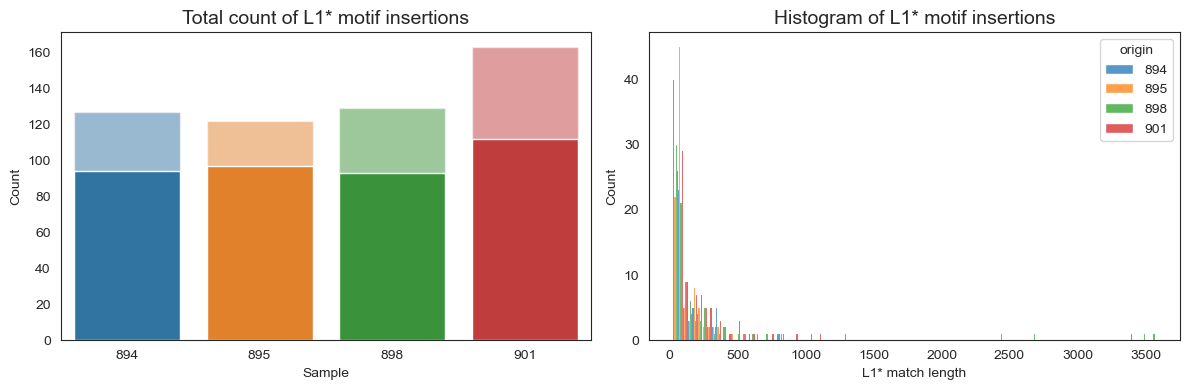

In [16]:
# Figure modified to show "cut down" of calls with filtering to exclude ambiguous chr placements and rough limiting of ref/alt counts
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 4))
axes = axes.flatten()

sns.countplot(ax = axes[0], data = L1_samples, x = 'origin', hue = 'origin', alpha = 0.5)
sns.countplot(ax = axes[0], data = L1_samples[~L1_samples['#CHROM'].str.contains('_')].query("ref_reads <= 70 & alt_reads <= 5"), x = 'origin', hue = 'origin')
axes[0].set_title("Total count of L1* motif insertions", size = 14)
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Count")

sns.histplot(ax = axes[1], data = L1_samples[~L1_samples['#CHROM'].str.contains('_')].query("ref_reads <= 70 & alt_reads <= 5"), x = 'match_len', hue = 'origin', multiple="dodge")
axes[1].set_title("Histogram of L1* motif insertions", size = 14)
axes[1].set_xlabel("L1* match length")
axes[1].set_ylabel("Count")

plt.tight_layout()